# MNIST Handwritten Digit Classification with CNNs

Welcome to our first hands-on computer vision project! In this walkthrough, we'll take everything we just learned about **image preprocessing**, **convolutional neural networks**, and **CNN architectures** and apply it to a real dataset.

### What is MNIST?

MNIST (Modified National Institute of Standards and Technology) is the "Hello World" of computer vision. It contains:

- **70,000** handwritten digit images (0-9)
- **60,000** for training, **10,000** for testing
- Each image is **28 x 28 pixels**, **grayscale**
- It's been used since the late 1990s to benchmark image classification models

### Our Goal

Build a CNN that can look at a handwritten digit and correctly classify it as 0, 1, 2, ... or 9.

This is an **image classification** task — the first of the three computer vision tasks we discussed in lecture!

---

## Step 1: Setup & Imports

Let's import the tools we'll need. We're using **TensorFlow/Keras** to build our CNN.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow version: {tf.__version__}")
print("Setup complete!")

TensorFlow version: 2.16.1
Setup complete!


---

## Step 2: Load the Data

MNIST comes built into Keras, so loading it is just one line. It automatically splits into training and testing sets.

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Training images: {X_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Test images:     {X_test.shape}")
print(f"Test labels:     {y_test.shape}")

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images:     (10000, 28, 28)
Test labels:     (10000,)


**Let's break down what we see:**

- `(60000, 28, 28)` — 60,000 images, each 28 pixels tall and 28 pixels wide
- `(60000,)` — 60,000 labels (one for each image)
- Same structure for the test set, just with 10,000 images

Each image is a 2D grid of numbers — exactly like the Lincoln pixel grid from our slides!

---

## Step 3: Exploring the Data — What Do These Images Look Like?

Remember from lecture: **to a computer, images are just numbers.** Let's see both the human view and the computer view.

### 3a: Visualize Some Digits

Let's look at a grid of sample images to see what we're working with.

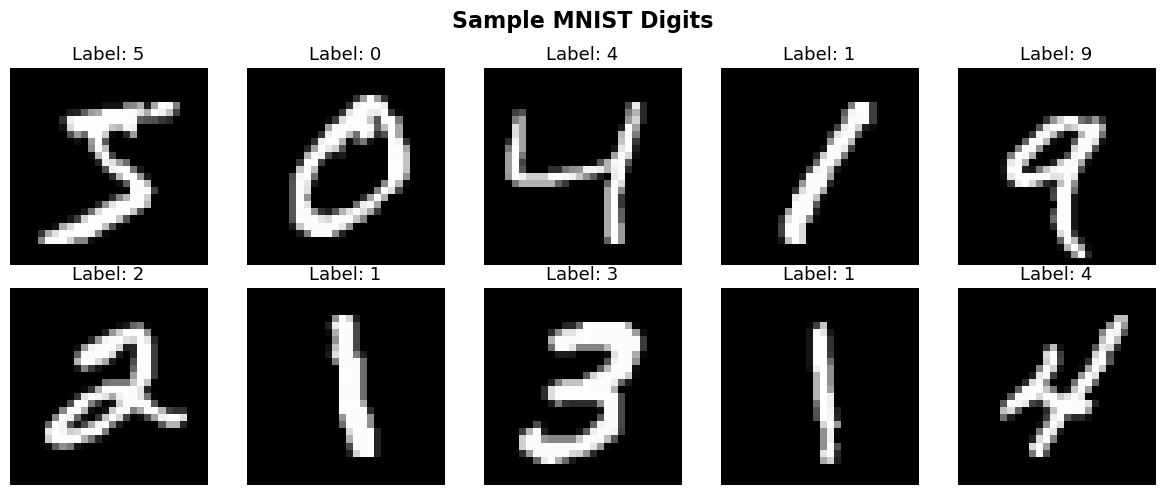

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample MNIST Digits", fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}", fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 3b: What the Computer Actually Sees

Remember the Lincoln pixel grid? Let's see the actual numbers behind one of these digit images. **This is what the CNN receives as input — not the picture, but the numbers.**

In [4]:
sample_image = X_train[0]
sample_label = y_train[0]

print(f"This image is labeled: {sample_label}")
print(f"Image shape: {sample_image.shape}")
print(f"Pixel value range: {sample_image.min()} to {sample_image.max()}")
print(f"\nThe raw pixel values (28x28 grid of numbers):\n")

for row in sample_image:
    print(" ".join(f"{val:3d}" for val in row))

This image is labeled: 5
Image shape: (28, 28)
Pixel value range: 0 to 255

The raw pixel values (28x28 grid of numbers):

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0
  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0
  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39  

### 3c: Understanding the Labels

Let's check how many examples we have of each digit. A balanced dataset means the model sees roughly equal numbers of each class.

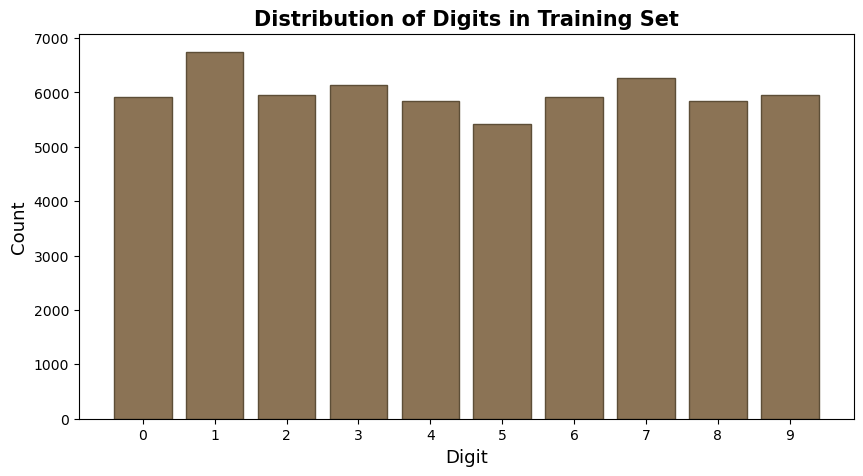

Digit counts:
  Digit 0: 5,923 images
  Digit 1: 6,742 images
  Digit 2: 5,958 images
  Digit 3: 6,131 images
  Digit 4: 5,842 images
  Digit 5: 5,421 images
  Digit 6: 5,918 images
  Digit 7: 6,265 images
  Digit 8: 5,851 images
  Digit 9: 5,949 images


In [5]:
# Count how many of each digit
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(unique, counts, color='#8B7355', edgecolor='#5D4E37')
plt.xlabel('Digit', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.title('Distribution of Digits in Training Set', fontsize=15, fontweight='bold')
plt.xticks(unique)
plt.show()

print("Digit counts:")
for digit, count in zip(unique, counts):
    print(f"  Digit {digit}: {count:,} images")

---

## Step 4: Preprocessing — Preparing Images for Our CNN

Remember from lecture: **"We prep images the same way a chef preps ingredients before cooking."**

We need to do three things before feeding images into our CNN:

1. **Normalize** pixel values (0-255 → 0-1)
2. **Reshape** to include the channel dimension
3. **One-hot encode** the labels

### 4a: Normalize Pixel Values

Neural networks work much better with small numbers. We divide every pixel value by 255 to scale them from the range **0-255** down to **0-1**.

**Why?** Large pixel values can cause large, unstable weight updates during training. Normalization keeps the math well-behaved.

In [6]:
# Before normalization
print(f"Before normalization:")
print(f"  Min pixel value: {X_train.min()}")
print(f"  Max pixel value: {X_train.max()}")
print(f"  Data type: {X_train.dtype}")

# Normalize: divide by 255 to get values between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"\nAfter normalization:")
print(f"  Min pixel value: {X_train.min()}")
print(f"  Max pixel value: {X_train.max()}")
print(f"  Data type: {X_train.dtype}")

Before normalization:
  Min pixel value: 0
  Max pixel value: 255
  Data type: uint8

After normalization:
  Min pixel value: 0.0
  Max pixel value: 1.0
  Data type: float32


### 4b: Reshape for CNN Input

Our images are currently shaped as `(28, 28)` — height and width. But CNNs expect a **channel dimension** too:

- **Color images (RGB):** shape would be `(28, 28, 3)` — 3 channels
- **Grayscale images:** shape should be `(28, 28, 1)` — 1 channel

We need to add that extra dimension.

In [7]:
print(f"Before reshape: {X_train.shape}")

# Reshape to add channel dimension: (samples, height, width, channels)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"After reshape:  {X_train.shape}")
print(f"\nThe CNN now knows: 60,000 images, 28px tall, 28px wide, 1 color channel (grayscale)")

Before reshape: (60000, 28, 28)
After reshape:  (60000, 28, 28, 1)

The CNN now knows: 60,000 images, 28px tall, 28px wide, 1 color channel (grayscale)


### 4c: One-Hot Encode the Labels

Our labels are currently single numbers (0, 1, 2, ... 9). But our CNN's output layer will have **10 neurons** — one for each digit. We need to convert labels to match.

For example, the digit **3** becomes: `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`

In [8]:
print(f"Before one-hot encoding:")
print(f"  Label for first image: {y_train[0]}")
print(f"  Shape: {y_train.shape}")

num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print(f"\nAfter one-hot encoding:")
print(f"  Label for first image: {y_train[0]}")
print(f"  Shape: {y_train.shape}")
print(f"\nEach label is now a vector of 10 numbers — one for each digit class.")

Before one-hot encoding:
  Label for first image: 5
  Shape: (60000,)

After one-hot encoding:
  Label for first image: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
  Shape: (60000, 10)

Each label is now a vector of 10 numbers — one for each digit class.


### Preprocessing Summary

| Step | Before | After | Why |
|------|--------|-------|-----|
| **Normalize** | 0-255 | 0-1 | Stable training |
| **Reshape** | (28, 28) | (28, 28, 1) | CNN needs channel dimension |
| **One-Hot Encode** | 5 | [0,0,0,0,0,1,0,0,0,0] | Match output layer format |

---

## Step 5: Building Our CNN

Now the exciting part! Let's build the CNN architecture we discussed in lecture. Remember the pipeline:

**Input → [Conv + ReLU → Pooling] × 2 → Flatten → Dense → Output**

We'll add each layer one at a time and explain what it does.

In [29]:
model = keras.Sequential([
    
    # === FEATURE LEARNING BLOCK 1 ===
    # Convolutional Layer: 32 filters, each 3x3
    # These filters will learn to detect basic features like edges and curves
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    
    # Max Pooling: Reduce size by half (2x2 window)
    # Keeps the strongest activations, reduces computation
    layers.MaxPooling2D((2, 2)),
    
    # === FEATURE LEARNING BLOCK 2 ===
    # More filters (64) to detect more complex patterns
    # Deeper layers learn higher-level features (shapes, parts of digits)
    layers.Conv2D(64, (3, 3), activation='relu'),
    
    # Max Pooling again: Further reduce spatial dimensions
    layers.MaxPooling2D((2, 2)),
    
    # === CLASSIFICATION BLOCK ===
    # Flatten: Convert 2D feature maps to 1D vector
    # This is the bridge between feature learning and classification
    layers.Flatten(),
    
    # Dense Layer: 128 neurons to learn patterns from extracted features
    layers.Dense(128, activation='relu'),
    
    # Dropout: Randomly turn off 50% of neurons during training
    # This prevents overfitting (remember: memorizing vs understanding!)
    layers.Dropout(0.7),
    
    # Output Layer: 10 neurons (one per digit), softmax gives probabilities
    layers.Dense(num_classes, activation='softmax')
])

print("Model built successfully!")

Model built successfully!


### Let's Look at Our Architecture

The model summary shows every layer, its output shape, and how many parameters (weights) it has to learn.

In [30]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

**Key things to notice:**

- **Conv2D layers** have parameters — these are the filter weights the network will learn!
- **MaxPooling layers** have 0 parameters — they just downsample, no learning needed
- **Flatten** has 0 parameters — it just reshapes
- The **Dense layer** has the most parameters — this is where classification decisions are made
- **Total trainable parameters** — these are ALL the numbers the network adjusts during training

---

## Step 6: Compile the Model

Before training, we need to tell Keras three things:

- **Optimizer:** *How* to update weights (Adam — an efficient variant of gradient descent)
- **Loss function:** *What* to minimize (categorical crossentropy — standard for multi-class classification)
- **Metrics:** *What* to track (accuracy — percentage of correct predictions)

In [31]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled and ready to train!")

Model compiled and ready to train!


---

## Step 7: Train the Model

Now we train! Remember the training loop from lecture:

1. **Forward Pass** — image goes through all layers, produces prediction
2. **Calculate Loss** — compare prediction to true label
3. **Backpropagation** — calculate gradients
4. **Update Weights** — adjust filters and connections
5. **Repeat!**

We'll train for **10 epochs** (10 full passes through all 60,000 training images) with a **batch size of 128** (process 128 images at a time).

We also pass in our test data as `validation_data` so we can watch how well the model does on unseen images as it trains.

In [32]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test),
    verbose=1
)

print("\nTraining complete!")

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.8602 - loss: 0.4570 - val_accuracy: 0.9734 - val_loss: 0.0976
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9516 - loss: 0.1794 - val_accuracy: 0.9830 - val_loss: 0.0601
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9636 - loss: 0.1368 - val_accuracy: 0.9860 - val_loss: 0.0455
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9707 - loss: 0.1107 - val_accuracy: 0.9873 - val_loss: 0.0429
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9722 - loss: 0.1028 - val_accuracy: 0.9884 - val_loss: 0.0384
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9751 - loss: 0.0918 - val_accuracy: 0.9898 - val_loss: 0.0355
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9766 - loss: 0.0886 - val_accuracy: 0.9892 - val_loss: 0.0401
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9774 - loss: 0.0870 - va

### Visualize Training Progress

Let's plot how accuracy and loss changed over the epochs. Ideally we want:
- **Accuracy** going UP
- **Loss** going DOWN
- Training and validation curves staying CLOSE together (if they diverge = overfitting!)

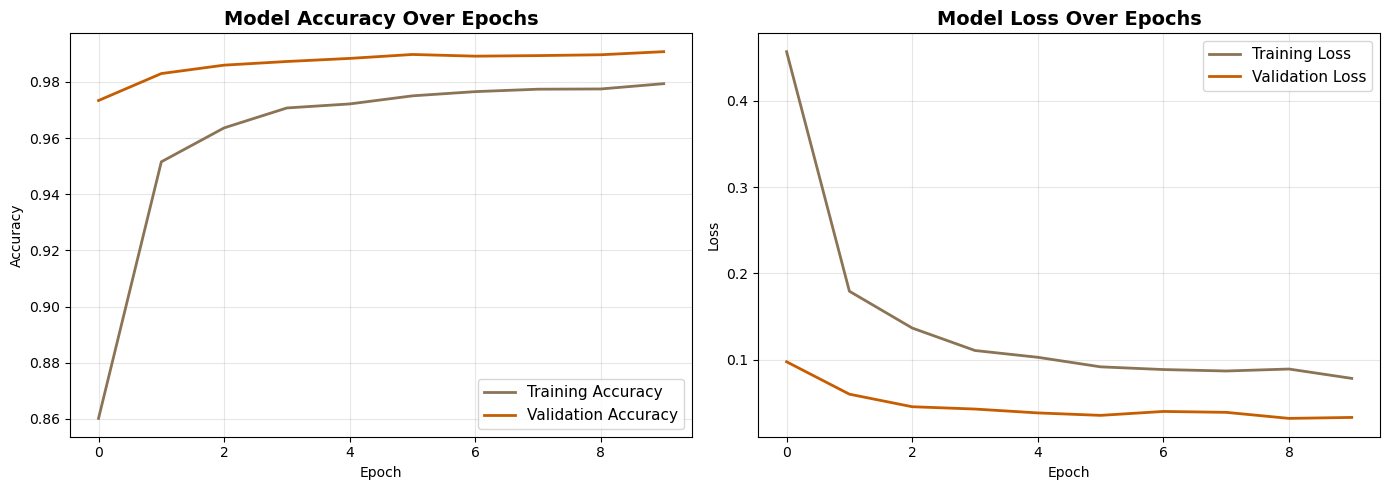

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='#8B7355')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#C65D00')
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2, color='#8B7355')
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='#C65D00')
axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## Step 8: Evaluate on Test Data

Training accuracy tells us how well the model learned the training data. But the real question is: **how does it perform on images it has never seen before?**

This is like the difference between studying practice problems vs taking the real exam.

In [34]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss:     {test_loss:.4f}")
print(f"\nOur CNN correctly classifies {test_accuracy*100:.2f}% of handwritten digits it has never seen before!")

Test Accuracy: 0.9908 (99.08%)
Test Loss:     0.0331

Our CNN correctly classifies 99.08% of handwritten digits it has never seen before!


---

## Step 9: Visualize Predictions

Let's see our model in action! We'll show test images alongside the model's predictions.

### 9a: Sample Predictions

Green title = correct prediction, Red title = wrong prediction.

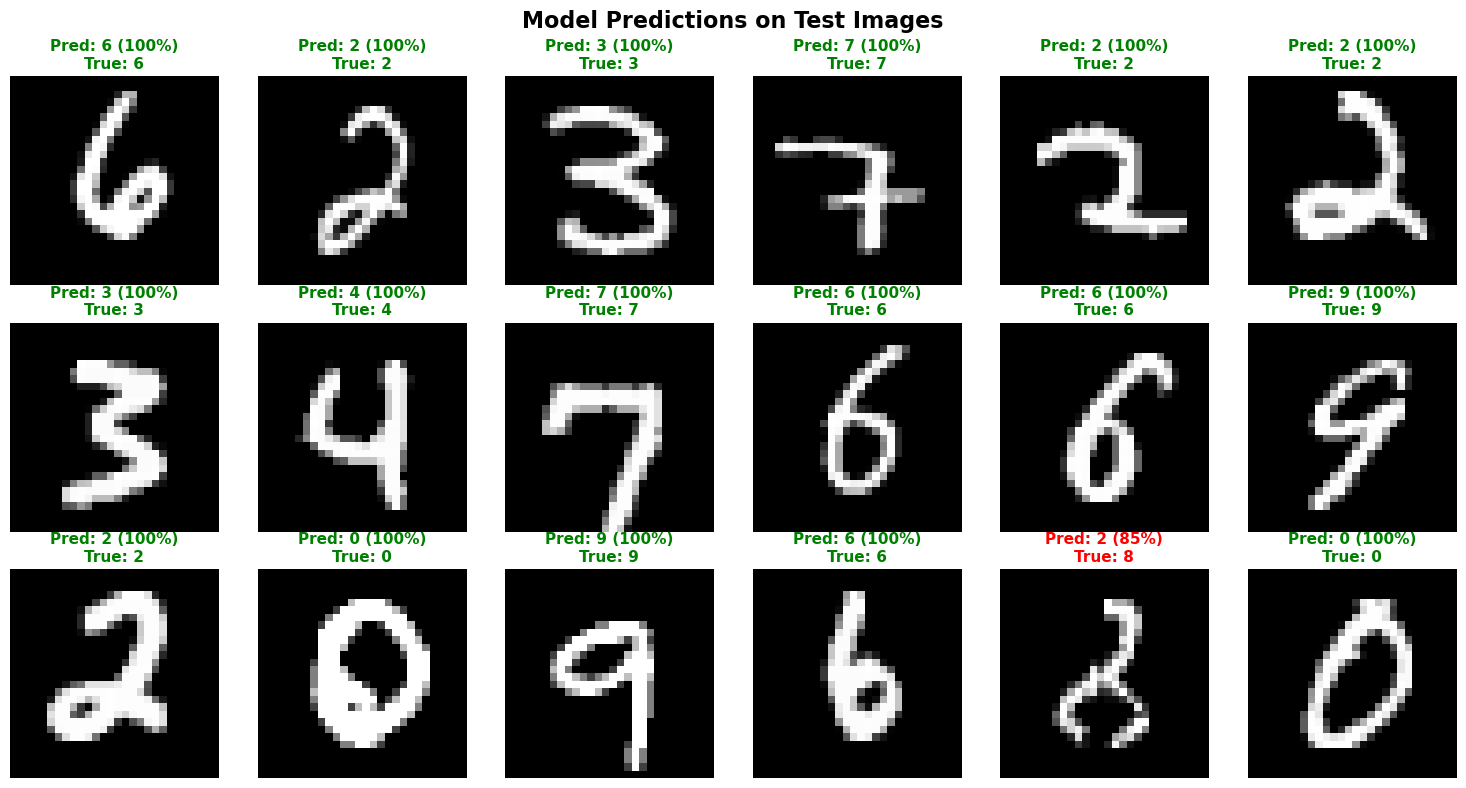

In [35]:
# Get predictions for test set
predictions = model.predict(X_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Display a grid of predictions
fig, axes = plt.subplots(3, 6, figsize=(15, 8))
fig.suptitle("Model Predictions on Test Images", fontsize=16, fontweight='bold')

# Pick random test images
np.random.seed(42)
random_indices = np.random.choice(len(X_test), 18, replace=False)

for i, ax in enumerate(axes.flat):
    idx = random_indices[i]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    
    pred = predicted_labels[idx]
    true = true_labels[idx]
    confidence = predictions[idx][pred] * 100
    
    color = 'green' if pred == true else 'red'
    ax.set_title(f"Pred: {pred} ({confidence:.0f}%)\nTrue: {true}", 
                 fontsize=11, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

### 9b: Confidence Scores for a Single Prediction

Remember softmax? It gives us a **probability** for each class. Let's see the full confidence breakdown for one image.

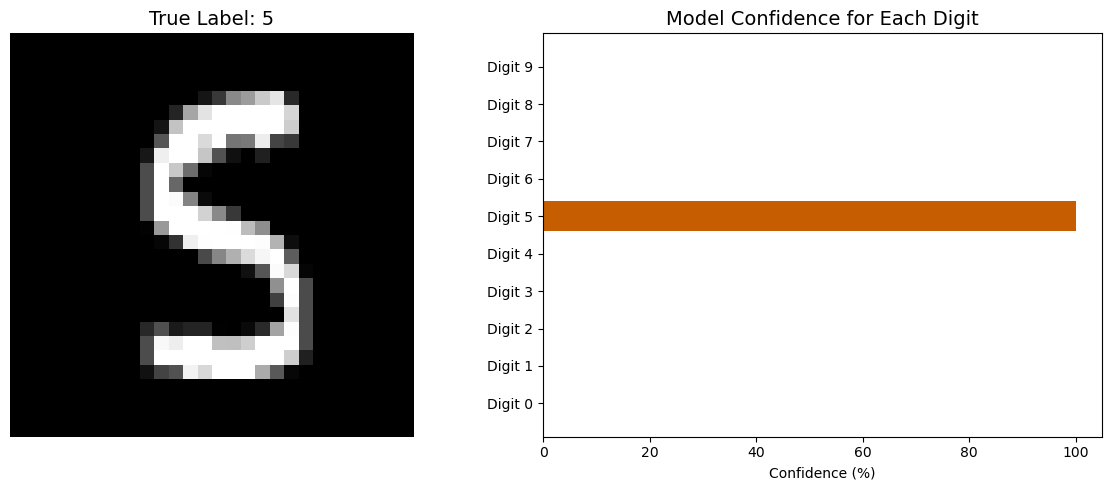

The model is 100.0% confident this is a 5


In [16]:
# Pick a sample image
sample_idx = 240
sample_pred = predictions[sample_idx]
sample_true = true_labels[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(X_test[sample_idx].reshape(28, 28), cmap='gray')
axes[0].set_title(f"True Label: {sample_true}", fontsize=14)
axes[0].axis('off')

colors = ['#C65D00' if i == np.argmax(sample_pred) else '#8B7355' for i in range(10)]
axes[1].barh(range(10), sample_pred * 100, color=colors)
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([f'Digit {i}' for i in range(10)])
axes[1].set_xlabel('Confidence (%)')
axes[1].set_title('Model Confidence for Each Digit', fontsize=14)

plt.tight_layout()
plt.show()

print(f"The model is {sample_pred[np.argmax(sample_pred)]*100:.1f}% confident this is a {np.argmax(sample_pred)}")

### 9c: Confusion Matrix — Where Does the Model Struggle?

A confusion matrix shows us which digits the model confuses with each other. The diagonal should be dark (correct predictions), while off-diagonal values represent mistakes.

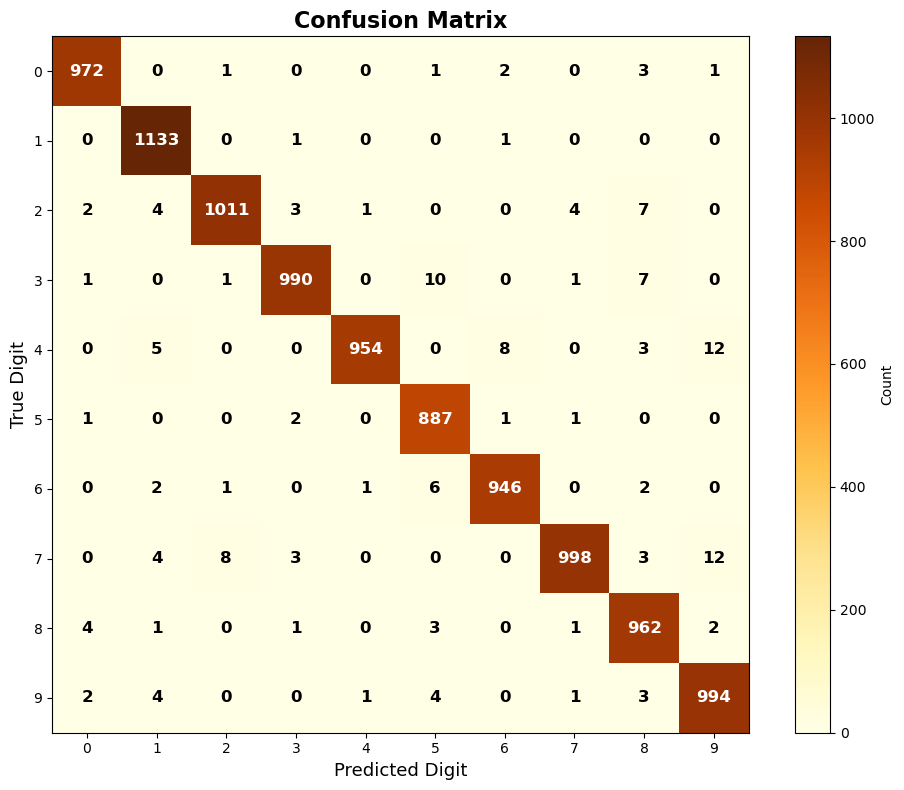

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='YlOrBr')
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.colorbar(label='Count')

for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', 
                 fontsize=12, color=color, fontweight='bold')

plt.xlabel('Predicted Digit', fontsize=13)
plt.ylabel('True Digit', fontsize=13)
plt.xticks(range(10))
plt.yticks(range(10))
plt.tight_layout()
plt.show()

### 9d: Let's Look at the Mistakes

The most interesting images are the ones the model gets **wrong**. These often reveal ambiguous handwriting that even humans might struggle with.

Total misclassified: 153 out of 10000 (1.53%)


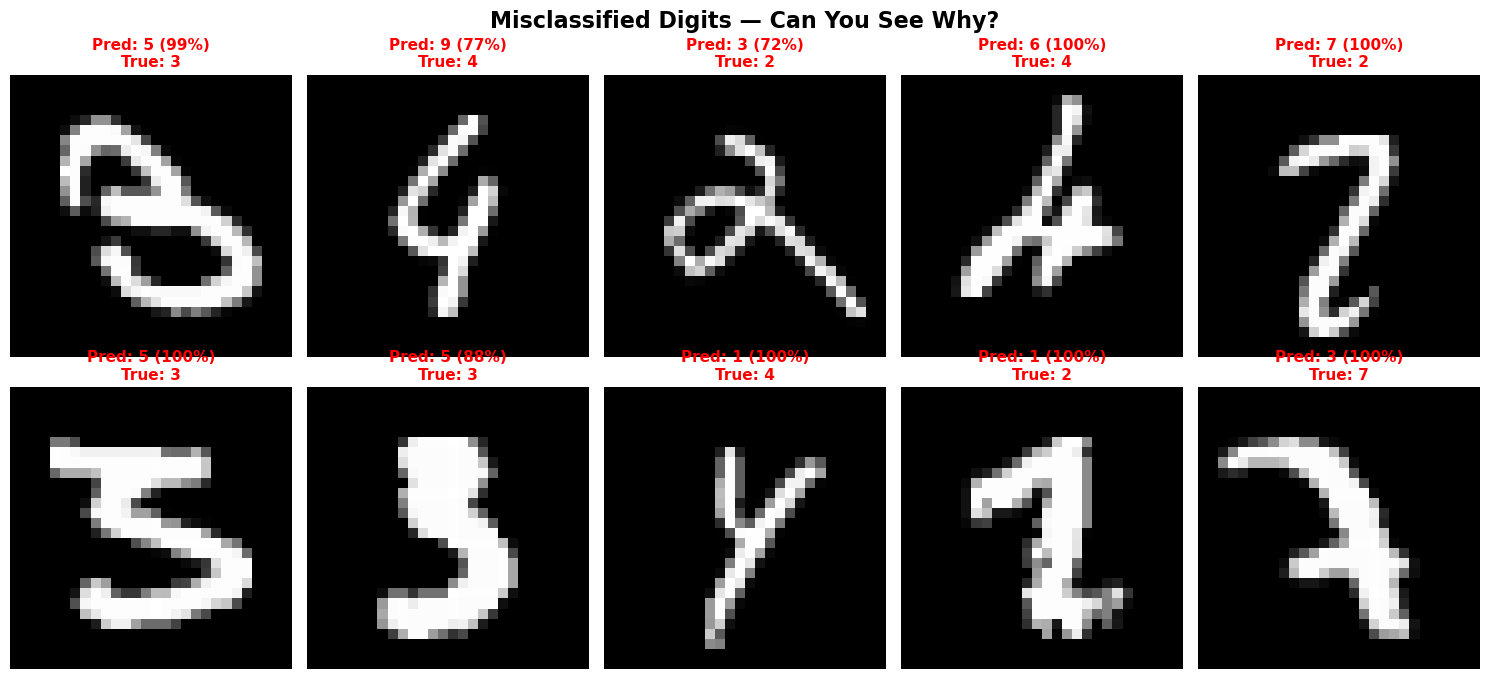


Notice: Many of these are digits that even humans might find ambiguous!
This is a great reminder that our model's mistakes often reflect genuinely hard cases.


In [23]:
misclassified = np.where(predicted_labels != true_labels)[0]
print(f"Total misclassified: {len(misclassified)} out of {len(true_labels)} ({len(misclassified)/len(true_labels)*100:.2f}%)")

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle("Misclassified Digits — Can You See Why?", fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(misclassified):
        idx = misclassified[i]
        ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
        confidence = predictions[idx][predicted_labels[idx]] * 100
        ax.set_title(f"Pred: {predicted_labels[idx]} ({confidence:.0f}%)\nTrue: {true_labels[idx]}", 
                     fontsize=11, color='red', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\nNotice: Many of these are digits that even humans might find ambiguous!")
print("This is a great reminder that our model's mistakes often reflect genuinely hard cases.")

---

## Bonus: Visualizing What the CNN Learned

One of the coolest things about CNNs is that we can actually **look at what the filters learned**. Remember from lecture:
- **Early layers** learn simple features (edges, lines)
- **Deeper layers** learn complex features (shapes, patterns)

Let's peek inside our trained model!

### Bonus A: First Layer Filters

These are the 32 filters (3x3 grids) that the first convolutional layer learned. Each one detects a different low-level feature.

First layer filter shape: (3, 3, 1, 32)
That's 32 filters, each 3x3 pixels, 1 channel (grayscale)



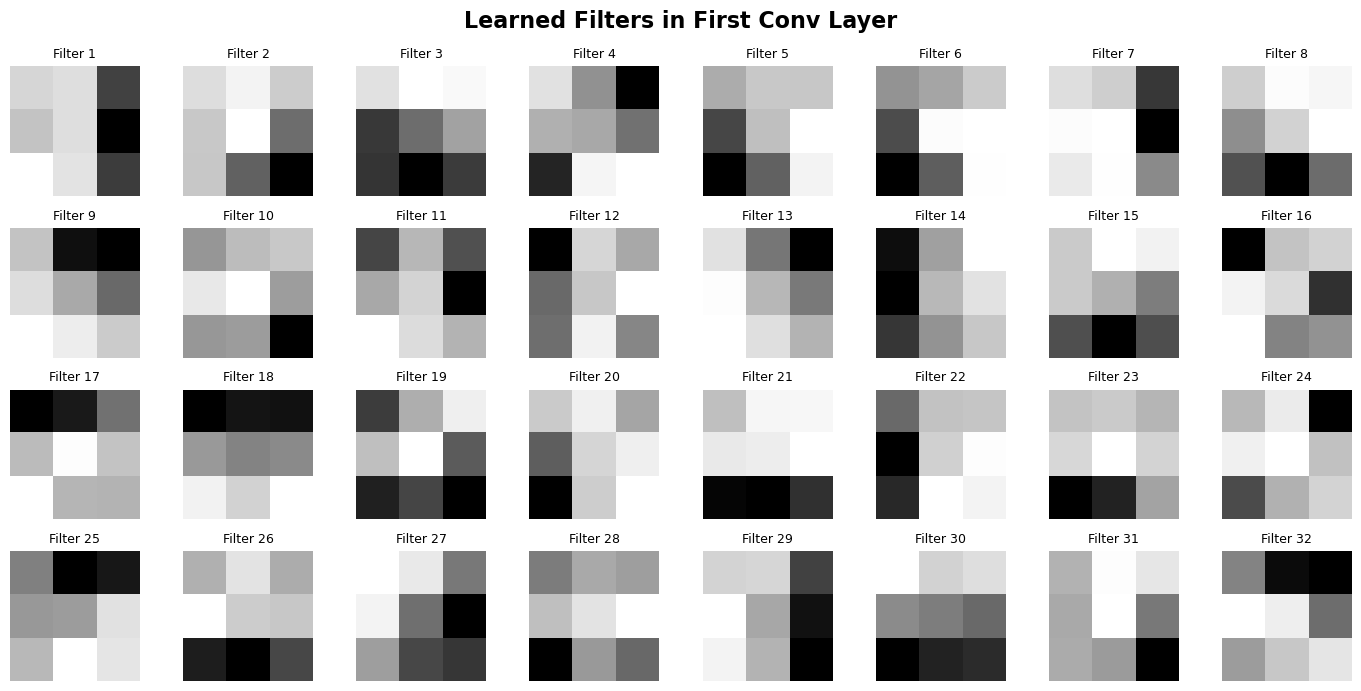

Each filter is a tiny 3x3 pattern detector.
Some detect vertical edges, some horizontal, some diagonal — the network figured this out on its own!


In [19]:
# Get the weights from the first convolutional layer
first_layer_weights = model.layers[0].get_weights()[0]  # Shape: (3, 3, 1, 32)

print(f"First layer filter shape: {first_layer_weights.shape}")
print(f"That's 32 filters, each 3x3 pixels, 1 channel (grayscale)\n")

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle("Learned Filters in First Conv Layer", fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    filt = first_layer_weights[:, :, 0, i]
    ax.imshow(filt, cmap='gray', interpolation='nearest')
    ax.set_title(f"Filter {i+1}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("Each filter is a tiny 3x3 pattern detector.")
print("Some detect vertical edges, some horizontal, some diagonal — the network figured this out on its own!")

### Bonus B: Feature Maps — What Does the Network See?

Let's pass a single image through the first convolutional layer and see the **feature maps** it produces. Each filter creates a different "view" of the image.

Input image shape: (1, 28, 28, 1)
Feature maps shape: (1, 26, 26, 32)
The 32 filters produced 32 feature maps, each 26x26 pixels



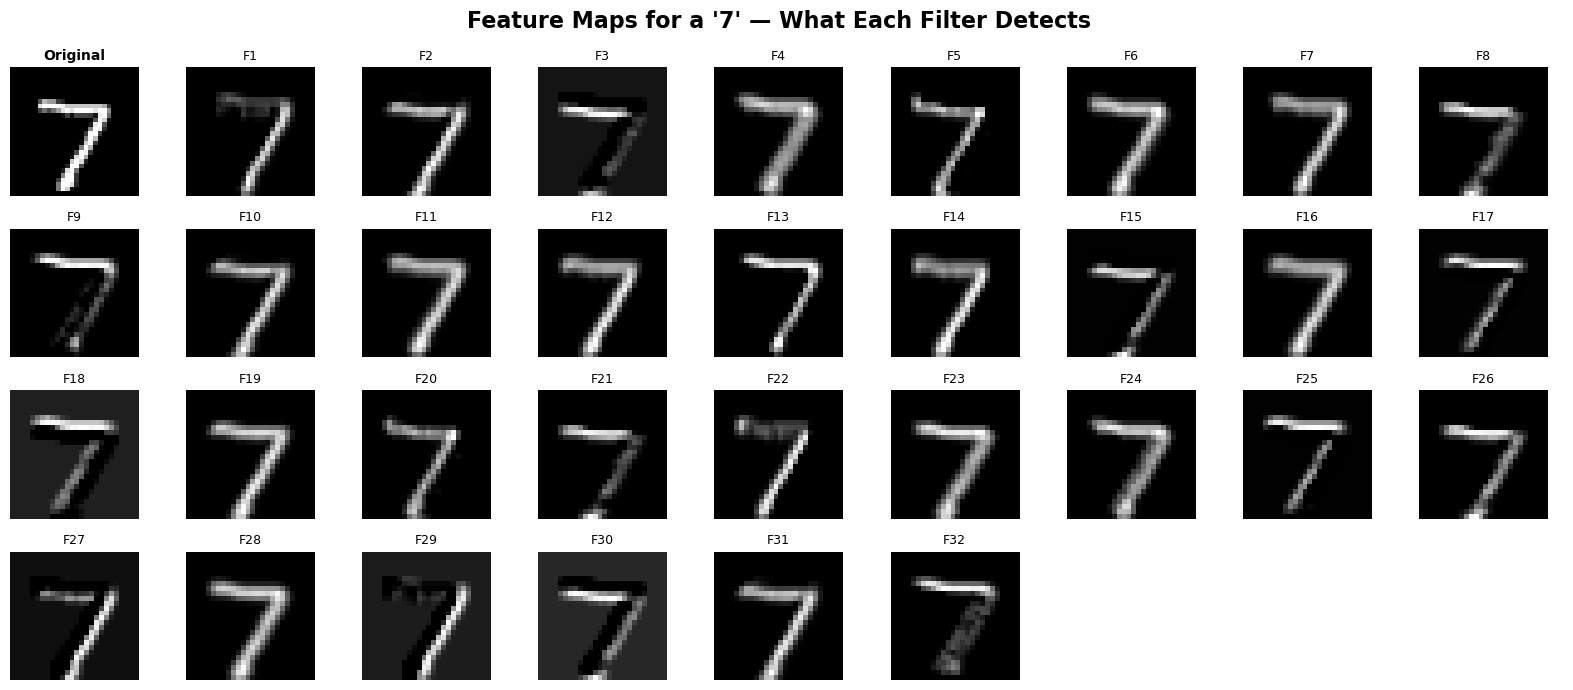

Notice how different filters highlight different parts of the digit!
Some emphasize edges, some focus on curves, some detect specific strokes.
The CNN combines ALL of these views to make its classification decision.


In [20]:
feature_map_model = keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

sample = X_test[0:1]  # Shape: (1, 28, 28, 1)
feature_maps = feature_map_model.predict(sample, verbose=0)

print(f"Input image shape: {sample.shape}")
print(f"Feature maps shape: {feature_maps.shape}")
print(f"The 32 filters produced 32 feature maps, each 26x26 pixels\n")

fig, axes = plt.subplots(4, 9, figsize=(16, 7))
fig.suptitle(f"Feature Maps for a '{true_labels[0]}' — What Each Filter Detects", fontsize=16, fontweight='bold')

axes[0, 0].imshow(sample.reshape(28, 28), cmap='gray')
axes[0, 0].set_title('Original', fontsize=10, fontweight='bold')
axes[0, 0].axis('off')

for i in range(32):
    row = (i + 1) // 9
    col = (i + 1) % 9
    axes[row, col].imshow(feature_maps[0, :, :, i], cmap='gray')
    axes[row, col].set_title(f'F{i+1}', fontsize=9)
    axes[row, col].axis('off')

for i in range(33, 36):
    row = i // 9
    col = i % 9
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("Notice how different filters highlight different parts of the digit!")
print("Some emphasize edges, some focus on curves, some detect specific strokes.")
print("The CNN combines ALL of these views to make its classification decision.")

---

## Recap: What We Built Today

Let's connect everything back to what we learned in lecture:

| Lecture Concept | What We Did |
|----------------|-------------|
| **Images are numbers** | Saw raw pixel values (0-255) behind digit images |
| **Image Preprocessing** | Normalized (0-1), reshaped (added channel), one-hot encoded labels |
| **Convolutional Layers** | Added Conv2D layers with learnable filters |
| **Feature Maps** | Visualized what each filter detects in an image |
| **Pooling** | Used MaxPooling to downsample and retain key features |
| **Flatten + Dense** | Bridged from feature maps to classification |
| **Softmax Output** | Got probability scores for each digit (0-9) |
| **Training Loop** | Watched accuracy improve over 10 epochs |
| **Overfitting Check** | Compared training vs validation curves |
| **Feature Hierarchy** | Saw that first-layer filters learn edges — just like we discussed! |

### What's Next?

In our next class, we'll dive deeper into computer vision — exploring more advanced CNN architectures, transfer learning, and tackling more complex image datasets.

Great work today! You just built your first computer vision model from scratch.